# Isotropy-Aware Adaptive Fine-Tuning for Cross-Lingual Alignment

**Core idea:** Vanilla InfoNCE improves cross-lingual alignment (Procrustes ↑) but collapses representation isotropy (IntraCos ↑ = bad). These two signals move in opposite directions across layers. We introduce:

1. A **composite per-layer score** = `Procrustes - α * IntraCos` that captures both alignment quality and isotropy health
2. **Adaptive per-layer learning rates** scaled by this score — well-aligned *and* isotropic layers get smaller updates; poorly-aligned or collapsed layers get larger updates
3. An **isotropy regularization loss** term that directly penalizes anisotropic collapse during training

**Data:** OPUS-100 EN-ES (train), Tatoeba EN-ES (eval) — no exotic dataset APIs needed.

In [6]:
!pip install -q datasets==2.18.0

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 510.5/510.5 kB 11.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 170.9/170.9 kB 20.7 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
gcsfs 2025.3.0 requires fsspec==2025.3.0, but you have fsspec 2024.2.0 which is incompatible.


In [1]:
!pip install -q transformers datasets sentencepiece scipy
print('✓ Done')

✓ Done


In [2]:
import torch
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import warnings
warnings.filterwarnings('ignore')

from transformers import AutoTokenizer, AutoModel, get_linear_schedule_with_warmup
from torch.optim import AdamW
from datasets import load_dataset
from scipy.linalg import orthogonal_procrustes
from collections import defaultdict

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device: {DEVICE}')
if DEVICE == 'cuda':
    print(f'GPU: {torch.cuda.get_device_name(0)}')

Device: cuda
GPU: NVIDIA A100-SXM4-40GB


In [3]:
# ── Config ────────────────────────────────────────────────────────────────────
MODEL_NAME    = 'xlm-roberta-base'
N_LAYERS      = 12
MAX_STEPS     = 800    # set to 2000 for full run
BATCH_SIZE    = 32
BASE_LR       = 2e-5
TEMPERATURE   = 0.07
WARMUP_STEPS  = 80
LOG_EVERY     = 100
PROBE_EVERY   = 200   # recompute composite scores every N steps
EVAL_N        = 200   # sentences for geometry eval
MAX_SEQ_LEN   = 64
ALPHA         = 0.5   # weight of intracos penalty in composite score
LAMBDA_ISO    = 0.05  # weight of isotropy regularization loss
LR_MIN_SCALE  = 0.1
LR_MAX_SCALE  = 2.0
print('✓ Config ready')

✓ Config ready


In [4]:
# ── Data: OPUS-100 EN-ES (train) + Tatoeba EN-ES (eval) ──────────────────────
# Both load reliably with no script issues
print('Loading OPUS-100 EN-ES (streaming)...')
opus_ds = load_dataset('Helsinki-NLP/opus-100', 'en-es', split='train', streaming=True)

def opus_stream():
    for ex in opus_ds:
        t = ex['translation']
        if 'en' in t and 'es' in t:
            yield t['en'], t['es']

print('Loading Tatoeba EN-ES (eval)...')
# Tatoeba is small, reliable, and gives us parallel EN-ES pairs for evaluation
tatoeba = load_dataset('Helsinki-NLP/tatoeba', lang1='en', lang2='es',
                       split='train', trust_remote_code=True) # Changed trust_remote_code to True

eval_en, eval_es = [], []
for ex in tatoeba:
    t = ex['translation']
    if 'en' in t and 'es' in t and len(t['en'].split()) > 3:
        eval_en.append(t['en'])
        eval_es.append(t['es'])
    if len(eval_en) >= EVAL_N:
        break

print(f'  Eval pairs: {len(eval_en)}')
print('✓ Data loaded')

Loading OPUS-100 EN-ES (streaming)...


Loading Tatoeba EN-ES (eval)...


Generating train split: 0 examples [00:00, ? examples/s]

  Eval pairs: 200
✓ Data loaded


In [5]:
# ── Model loading & encoding utils ───────────────────────────────────────────
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

def load_fresh_model():
    m = AutoModel.from_pretrained(MODEL_NAME, output_hidden_states=True)
    return m.to(DEVICE)

def tok(texts):
    return tokenizer(texts, padding=True, truncation=True,
                     max_length=MAX_SEQ_LEN, return_tensors='pt')

def mean_pool(hidden, mask):
    mask_exp = mask.unsqueeze(-1).float()
    return F.normalize((hidden * mask_exp).sum(1) / mask_exp.sum(1).clamp(1e-9), dim=-1)

@torch.no_grad()
def encode_all_layers(model, texts, batch_size=64):
    """Returns [N, n_layers+1, H] — all hidden states, mean-pooled."""
    model.eval()
    all_reps = []
    for i in range(0, len(texts), batch_size):
        enc = {k: v.to(DEVICE) for k, v in tok(texts[i:i+batch_size]).items()}
        hs  = model(**enc).hidden_states  # tuple of 13 x [B, T, H]
        pooled = torch.stack([mean_pool(h, enc['attention_mask']) for h in hs], dim=1)
        all_reps.append(pooled.cpu())
    return torch.cat(all_reps, dim=0)  # [N, 13, H]

def encode_final_train(model, input_ids, attention_mask):
    """Final-layer encode with gradients (for training)."""
    out = model(input_ids=input_ids, attention_mask=attention_mask)
    return mean_pool(out.last_hidden_state, attention_mask)

pretrained_model = load_fresh_model()
pretrained_model.eval()
# Cache pretrained representations for CKA drift computation
print('Caching pretrained representations...')
pretrained_en_reps = encode_all_layers(pretrained_model, eval_en)  # [N, 13, H]
pretrained_es_reps = encode_all_layers(pretrained_model, eval_es)
print('✓ Model ready')

config.json:   0%|          | 0.00/615 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/1.12G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

XLMRobertaModel LOAD REPORT from: xlm-roberta-base
Key                       | Status     |  | 
--------------------------+------------+--+-
lm_head.bias              | UNEXPECTED |  | 
lm_head.dense.weight      | UNEXPECTED |  | 
lm_head.dense.bias        | UNEXPECTED |  | 
lm_head.layer_norm.weight | UNEXPECTED |  | 
lm_head.layer_norm.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Caching pretrained representations...
✓ Model ready


In [6]:
# ── Geometry metrics ──────────────────────────────────────────────────────────
def procrustes_sim(X, Y):
    """1 - normalized Frobenius distance after orthogonal alignment. Higher = better."""
    X = X.numpy(); Y = Y.numpy()
    Xn = X / (np.linalg.norm(X, 'fro') + 1e-9)
    Yn = Y / (np.linalg.norm(Y, 'fro') + 1e-9)
    R, _ = orthogonal_procrustes(Xn, Yn)
    return float(1.0 - np.linalg.norm(Xn @ R - Yn, 'fro') / 2.0)

def intra_cos(X):
    """Mean pairwise cosine similarity. High = anisotropic (bad). Lower = better."""
    Xn = F.normalize(X, dim=-1)
    sim = Xn @ Xn.T
    mask = ~torch.eye(sim.size(0), dtype=torch.bool)
    return sim[mask].mean().item()

def cka(X, Y):
    """Linear CKA. Higher = more similar representations."""
    X = X - X.mean(0); Y = Y - Y.mean(0)
    num   = ((X @ Y.T) ** 2).sum()
    denom = torch.sqrt(((X @ X.T) ** 2).sum() * ((Y @ Y.T) ** 2).sum())
    return (num / denom).item()

def composite_score(proc, ic, alpha=ALPHA):
    """Higher composite = layer is well-aligned AND isotropic = less update needed."""
    return proc - alpha * ic

@torch.no_grad()
def evaluate_geometry(model):
    """Per-layer metrics for a model against pretrained baseline."""
    en_reps = encode_all_layers(model, eval_en)
    es_reps = encode_all_layers(model, eval_es)
    metrics = defaultdict(list)
    for l in range(1, N_LAYERS + 1):
        en_l = en_reps[:, l, :]
        es_l = es_reps[:, l, :]
        pre_l = pretrained_en_reps[:, l, :]
        proc = procrustes_sim(en_l, es_l)
        ic   = intra_cos(en_l)
        metrics['procrustes'].append(proc)
        metrics['intracos'].append(ic)
        metrics['cka_cross'].append(cka(en_l, es_l))
        metrics['cka_drift'].append(cka(en_l, pre_l))   # drift from pretrained
        metrics['composite'].append(composite_score(proc, ic))
    return dict(metrics)

print('Computing pretrained geometry baseline...')
pretrained_metrics = evaluate_geometry(pretrained_model)
print('✓ Baseline geometry computed')

Computing pretrained geometry baseline...
✓ Baseline geometry computed


In [7]:
# ── Isotropy regularization loss ──────────────────────────────────────────────
# Penalizes high mean pairwise cosine similarity within a batch.
# This directly counteracts the anisotropy collapse caused by InfoNCE.
def isotropy_reg_loss(z):
    """
    z: [B, H] normalized embeddings
    Returns mean off-diagonal cosine similarity (we minimize this).
    Equivalent to pushing representations to be more uniformly spread.
    """
    sim = z @ z.T  # [B, B], z is already L2-normalized
    B = sim.size(0)
    mask = ~torch.eye(B, dtype=torch.bool, device=sim.device)
    return sim[mask].mean()

def infonce_loss(z_src, z_tgt, tau=TEMPERATURE):
    sim = z_src @ z_tgt.T / tau
    labels = torch.arange(sim.size(0), device=sim.device)
    return (F.cross_entropy(sim, labels) + F.cross_entropy(sim.T, labels)) / 2.0

def combined_loss(z_src, z_tgt, lam=LAMBDA_ISO):
    """InfoNCE + isotropy regularization on both src and tgt embeddings."""
    l_align = infonce_loss(z_src, z_tgt)
    l_iso   = (isotropy_reg_loss(z_src) + isotropy_reg_loss(z_tgt)) / 2.0
    return l_align + lam * l_iso, l_align.item(), l_iso.item()

print('✓ Losses defined')

✓ Losses defined


In [8]:
# ── Adaptive LR scaling from composite score ──────────────────────────────────
def composite_to_lr_scales(composite_scores, min_s=LR_MIN_SCALE, max_s=LR_MAX_SCALE):
    """
    High composite score = layer already well-aligned AND isotropic
    → give it LESS update (lower LR). Invert so high score → low scale.
    """
    c = np.array(composite_scores)
    c_norm = (c - c.min()) / (c.max() - c.min() + 1e-9)  # 0=worst, 1=best
    # Invert: best layers get smallest LR
    scales = min_s + (max_s - min_s) * (1.0 - c_norm)
    return scales

def build_param_groups(model, base_lr, scales):
    groups = []
    groups.append({'params': list(model.embeddings.parameters()),
                   'lr': base_lr * float(scales[0])})
    for i, layer in enumerate(model.encoder.layer):
        groups.append({'params': list(layer.parameters()),
                       'lr': base_lr * float(scales[min(i, len(scales)-1)])})
    if hasattr(model, 'pooler') and model.pooler is not None:
        groups.append({'params': list(model.pooler.parameters()),
                       'lr': base_lr * float(scales[-1])})
    return groups

def get_batch_iter():
    buf = []
    for src, tgt in opus_stream():
        buf.append((src, tgt))
        if len(buf) < BATCH_SIZE:
            continue
        srcs, tgts = zip(*buf); buf = []
        yield ({k: v.to(DEVICE) for k, v in tok(list(srcs)).items()},
               {k: v.to(DEVICE) for k, v in tok(list(tgts)).items()})

print('✓ Adaptive utilities defined')

✓ Adaptive utilities defined


In [9]:
# ── BASELINE: Vanilla InfoNCE ─────────────────────────────────────────────────
print('='*55)
print('BASELINE: Vanilla InfoNCE (uniform LR, no iso reg)')
print('='*55)

vanilla_model = load_fresh_model()
opt_v = AdamW(vanilla_model.parameters(), lr=BASE_LR, weight_decay=0.01)
sch_v = get_linear_schedule_with_warmup(opt_v, WARMUP_STEPS, MAX_STEPS)

losses_v, step = [], 0
for src_enc, tgt_enc in get_batch_iter():
    vanilla_model.train()
    z_s = encode_final_train(vanilla_model, src_enc['input_ids'], src_enc['attention_mask'])
    z_t = encode_final_train(vanilla_model, tgt_enc['input_ids'], tgt_enc['attention_mask'])
    loss = infonce_loss(z_s, z_t)
    opt_v.zero_grad(); loss.backward()
    torch.nn.utils.clip_grad_norm_(vanilla_model.parameters(), 1.0)
    opt_v.step(); sch_v.step()
    losses_v.append(loss.item())
    step += 1
    if step % LOG_EVERY == 0:
        print(f'  step {step}/{MAX_STEPS}  loss={np.mean(losses_v[-LOG_EVERY:]):.4f}')
    if step >= MAX_STEPS: break

print('Evaluating...')
vanilla_metrics = evaluate_geometry(vanilla_model)
print('✓ Vanilla done')

BASELINE: Vanilla InfoNCE (uniform LR, no iso reg)


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

XLMRobertaModel LOAD REPORT from: xlm-roberta-base
Key                       | Status     |  | 
--------------------------+------------+--+-
lm_head.bias              | UNEXPECTED |  | 
lm_head.dense.weight      | UNEXPECTED |  | 
lm_head.dense.bias        | UNEXPECTED |  | 
lm_head.layer_norm.weight | UNEXPECTED |  | 
lm_head.layer_norm.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


  step 100/800  loss=2.7605
  step 200/800  loss=0.6843
  step 300/800  loss=0.3993
  step 400/800  loss=0.3290
  step 500/800  loss=0.2937
  step 600/800  loss=0.2676
  step 700/800  loss=0.2597
  step 800/800  loss=0.2285
Evaluating...
✓ Vanilla done


In [10]:
# ── OUR METHOD: Composite-Score Adaptive + Isotropy Reg ───────────────────────
print('='*55)
print('OURS: Composite-Adaptive LR + Isotropy Regularization')
print('='*55)

adaptive_model = load_fresh_model()

# Start with uniform scales; will be updated every PROBE_EVERY steps
current_scales  = np.ones(N_LAYERS)
scale_history   = []   # list of (step, scales array)
loss_breakdown  = []   # (step, total, align, iso)

param_groups = build_param_groups(adaptive_model, BASE_LR, current_scales)
opt_a = AdamW(param_groups, weight_decay=0.01)
sch_a = get_linear_schedule_with_warmup(opt_a, WARMUP_STEPS, MAX_STEPS)

losses_a, step = [], 0
for src_enc, tgt_enc in get_batch_iter():

    # ── Probe: recompute composite scores & update LR ────────────────────────
    if step > 0 and step % PROBE_EVERY == 0:
        print(f'\n  [step {step}] Probing geometry & rescaling LRs...')
        m = evaluate_geometry(adaptive_model)
        new_scales = composite_to_lr_scales(m['composite'])
        scale_history.append((step, new_scales.copy()))
        # Update optimizer LRs
        for i, pg in enumerate(opt_a.param_groups):
            layer_idx = max(0, i - 1)
            pg['lr'] = BASE_LR * float(new_scales[min(layer_idx, N_LAYERS-1)])
        current_scales = new_scales
        print(f'  Composite scores: min={min(m["composite"]):.3f} max={max(m["composite"]):.3f}')
        print(f'  LR scales:        min={new_scales.min():.2f}  max={new_scales.max():.2f}')
        most_protected = np.argsort(new_scales)[:3] + 1
        most_updated   = np.argsort(new_scales)[-3:] + 1
        print(f'  Most protected layers (low LR): {most_protected}')
        print(f'  Most updated layers  (high LR): {most_updated}')

    # ── Forward + combined loss ──────────────────────────────────────────────
    adaptive_model.train()
    z_s = encode_final_train(adaptive_model, src_enc['input_ids'], src_enc['attention_mask'])
    z_t = encode_final_train(adaptive_model, tgt_enc['input_ids'], tgt_enc['attention_mask'])
    loss, l_align, l_iso = combined_loss(z_s, z_t)

    opt_a.zero_grad(); loss.backward()
    torch.nn.utils.clip_grad_norm_(adaptive_model.parameters(), 1.0)
    opt_a.step(); sch_a.step()

    losses_a.append(loss.item())
    loss_breakdown.append((step, loss.item(), l_align, l_iso))
    step += 1

    if step % LOG_EVERY == 0:
        print(f'  step {step}/{MAX_STEPS}  loss={np.mean(losses_a[-LOG_EVERY:]):.4f}  '
              f'align={l_align:.4f}  iso={l_iso:.4f}')
    if step >= MAX_STEPS: break

print('\nEvaluating...')
adaptive_metrics = evaluate_geometry(adaptive_model)
print('✓ Adaptive method done')

OURS: Composite-Adaptive LR + Isotropy Regularization


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

XLMRobertaModel LOAD REPORT from: xlm-roberta-base
Key                       | Status     |  | 
--------------------------+------------+--+-
lm_head.bias              | UNEXPECTED |  | 
lm_head.dense.weight      | UNEXPECTED |  | 
lm_head.dense.bias        | UNEXPECTED |  | 
lm_head.layer_norm.weight | UNEXPECTED |  | 
lm_head.layer_norm.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


  step 100/800  loss=2.8530  align=1.5051  iso=0.3433
  step 200/800  loss=0.7463  align=0.4482  iso=0.1463

  [step 200] Probing geometry & rescaling LRs...
  Composite scores: min=0.453 max=0.707
  LR scales:        min=0.10  max=2.00
  Most protected layers (low LR): [12 11 10]
  Most updated layers  (high LR): [3 1 2]
  step 300/800  loss=0.4500  align=1.0402  iso=0.0877
  step 400/800  loss=0.3567  align=0.3428  iso=0.0577

  [step 400] Probing geometry & rescaling LRs...
  Composite scores: min=0.454 max=0.750
  LR scales:        min=0.10  max=2.00
  Most protected layers (low LR): [12 11 10]
  Most updated layers  (high LR): [3 1 2]
  step 500/800  loss=0.2974  align=0.6347  iso=0.0418
  step 600/800  loss=0.2690  align=0.4023  iso=0.0307

  [step 600] Probing geometry & rescaling LRs...
  Composite scores: min=0.454 max=0.769
  LR scales:        min=0.10  max=2.00
  Most protected layers (low LR): [12 11 10]
  Most updated layers  (high LR): [3 1 2]
  step 700/800  loss=0.2613 

In [11]:
# ── Retrieval evaluation ──────────────────────────────────────────────────────
@torch.no_grad()
def p_at_1(model):
    """EN→ES P@1 on eval set."""
    model.eval()
    enc_en = {k: v.to(DEVICE) for k, v in tok(eval_en).items()}
    enc_es = {k: v.to(DEVICE) for k, v in tok(eval_es).items()}
    en_r = mean_pool(model(**enc_en).last_hidden_state, enc_en['attention_mask']).cpu()
    es_r = mean_pool(model(**enc_es).last_hidden_state, enc_es['attention_mask']).cpu()
    sim  = en_r @ es_r.T
    hits = (sim.argmax(1) == torch.arange(len(eval_en))).float().mean().item()
    return hits

retrieval = {
    'Pretrained':   p_at_1(pretrained_model),
    'Vanilla':      p_at_1(vanilla_model),
    'Adaptive+Iso': p_at_1(adaptive_model),
}
print('\nEN→ES Retrieval P@1:')
for k, v in retrieval.items():
    print(f'  {k:<18} {v:.4f}')


EN→ES Retrieval P@1:
  Pretrained         0.3900
  Vanilla            0.6750
  Adaptive+Iso       0.6750


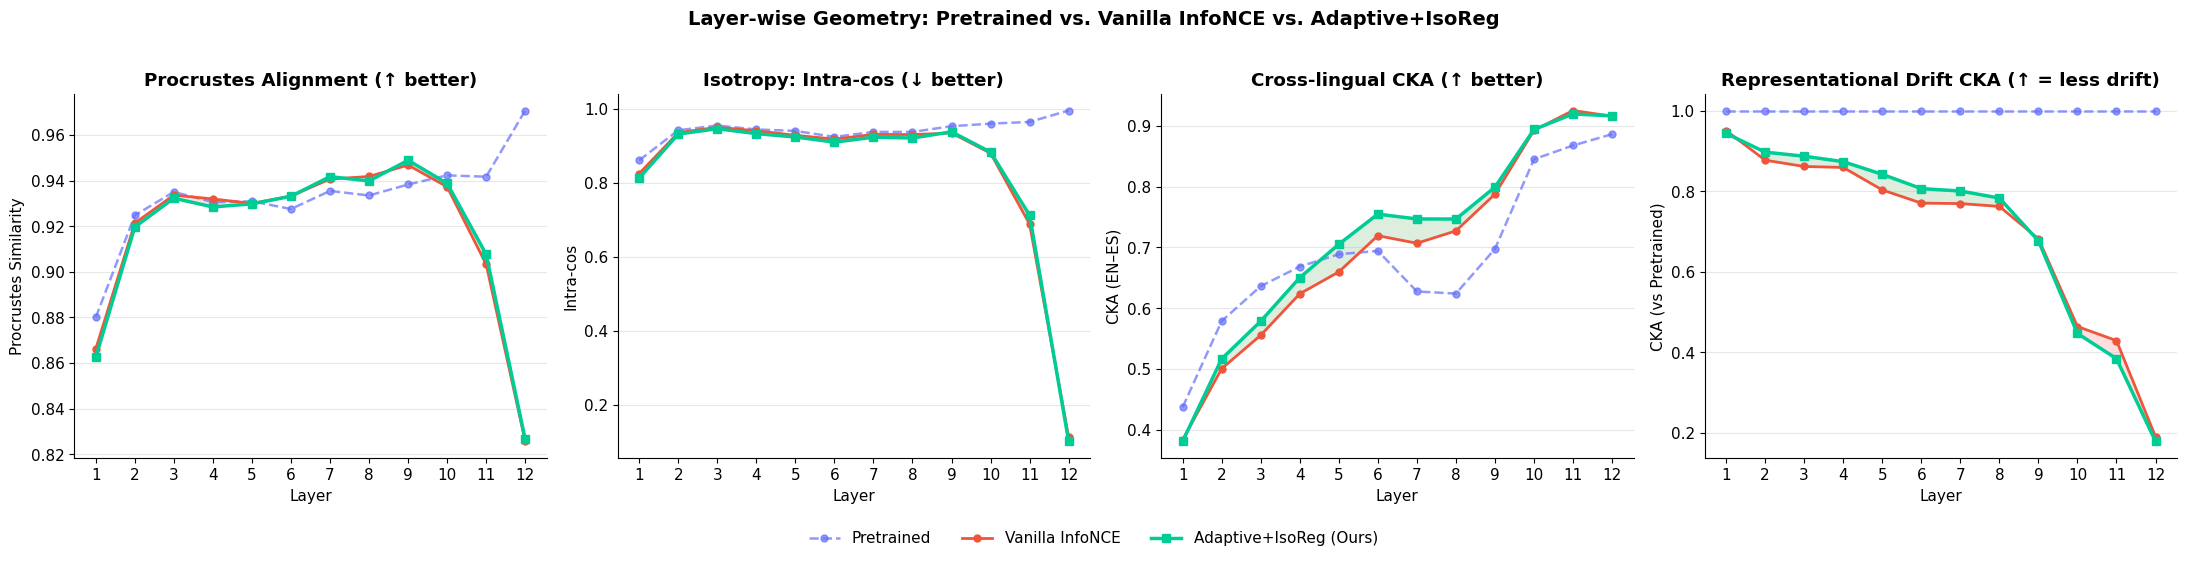

In [12]:
# ── PLOTS ─────────────────────────────────────────────────────────────────────
layers = list(range(1, N_LAYERS + 1))
C = {'pre': '#636EFA', 'van': '#EF553B', 'ada': '#00CC96'}
L = {'pre': 'Pretrained', 'van': 'Vanilla InfoNCE', 'ada': 'Adaptive+IsoReg (Ours)'}

plt.rcParams.update({'font.size': 11, 'axes.spines.top': False,
                     'axes.spines.right': False, 'figure.facecolor': 'white'})

# ── Figure 1: Core 4-panel layer-wise geometry ────────────────────────────────
fig, axes = plt.subplots(1, 4, figsize=(22, 5))
fig.suptitle('Layer-wise Geometry: Pretrained vs. Vanilla InfoNCE vs. Adaptive+IsoReg',
             fontsize=14, fontweight='bold', y=1.02)

panel_cfg = [
    ('procrustes', 'Procrustes Similarity', 'Procrustes Alignment (↑ better)', True),
    ('intracos',   'Intra-cos',             'Isotropy: Intra-cos (↓ better)',  False),
    ('cka_cross',  'CKA (EN–ES)',           'Cross-lingual CKA (↑ better)',    True),
    ('cka_drift',  'CKA (vs Pretrained)',   'Representational Drift CKA (↑ = less drift)', True),
]

for ax, (key, ylabel, title, higher_better) in zip(axes, panel_cfg):
    pre = pretrained_metrics[key]
    van = vanilla_metrics[key]
    ada = adaptive_metrics[key]
    ax.plot(layers, pre, 'o--', color=C['pre'], label=L['pre'], lw=1.8, ms=5, alpha=0.7)
    ax.plot(layers, van, 'o-',  color=C['van'], label=L['van'], lw=2,   ms=5)
    ax.plot(layers, ada, 's-',  color=C['ada'], label=L['ada'], lw=2.5, ms=6)
    van_a, ada_a = np.array(van), np.array(ada)
    imp = ada_a >= van_a if higher_better else ada_a <= van_a
    ax.fill_between(layers, van, ada, where=imp,  alpha=0.13, color='green')
    ax.fill_between(layers, van, ada, where=~imp, alpha=0.13, color='red')
    ax.set_xlabel('Layer'); ax.set_ylabel(ylabel)
    ax.set_title(title, fontweight='bold', pad=6)
    ax.set_xticks(layers); ax.grid(axis='y', alpha=0.3)

handles, lbls = axes[0].get_legend_handles_labels()
fig.legend(handles[:3], lbls[:3], loc='lower center', ncol=3,
           bbox_to_anchor=(0.5, -0.08), frameon=False, fontsize=11)
plt.tight_layout()
plt.savefig('fig1_layer_geometry.png', dpi=150, bbox_inches='tight')
plt.show()

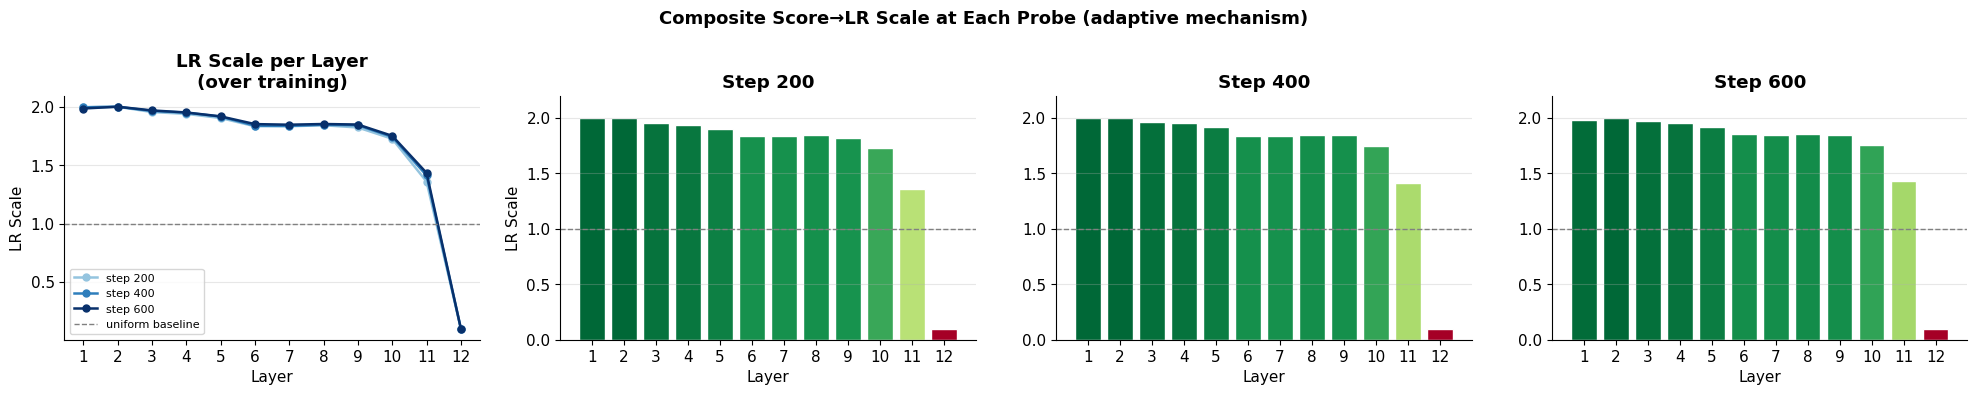

In [13]:
# ── Figure 2: Composite score & LR scale evolution ────────────────────────────
n_probes = len(scale_history)
if n_probes == 0:
    print('No probes recorded — increase MAX_STEPS or decrease PROBE_EVERY')
else:
    fig, axes = plt.subplots(1, n_probes + 1, figsize=(5 * (n_probes + 1), 4))
    if n_probes == 0: axes = [axes]
    fig.suptitle('Composite Score→LR Scale at Each Probe (adaptive mechanism)',
                 fontweight='bold', fontsize=13)

    # First panel: composite scores from each probe
    ax0 = axes[0]
    colors_probe = plt.cm.Blues(np.linspace(0.4, 1.0, n_probes))
    for idx, (step_n, scales) in enumerate(scale_history):
        # re-evaluate composite at that step (we only stored scales)
        ax0.plot(layers, scales, 'o-', color=colors_probe[idx],
                 label=f'step {step_n}', lw=1.8, ms=5)
    ax0.axhline(1.0, color='gray', ls='--', lw=1, label='uniform baseline')
    ax0.set_xlabel('Layer'); ax0.set_ylabel('LR Scale')
    ax0.set_title('LR Scale per Layer\n(over training)', fontweight='bold')
    ax0.legend(fontsize=8); ax0.set_xticks(layers); ax0.grid(axis='y', alpha=0.3)

    # One bar chart per probe
    for idx, (step_n, scales) in enumerate(scale_history):
        ax = axes[idx + 1]
        bar_cols = plt.cm.RdYlGn(
            (scales - LR_MIN_SCALE) / (LR_MAX_SCALE - LR_MIN_SCALE + 1e-9)
        )
        ax.bar(layers, scales, color=bar_cols, edgecolor='white')
        ax.axhline(1.0, color='gray', ls='--', lw=1)
        ax.set_xticks(layers); ax.set_xlabel('Layer')
        ax.set_ylabel('LR Scale') if idx == 0 else None
        ax.set_title(f'Step {step_n}', fontweight='bold')
        ax.set_ylim(0, LR_MAX_SCALE + 0.2); ax.grid(axis='y', alpha=0.3)

    plt.tight_layout()
    plt.savefig('fig2_lr_scales.png', dpi=150, bbox_inches='tight')
    plt.show()

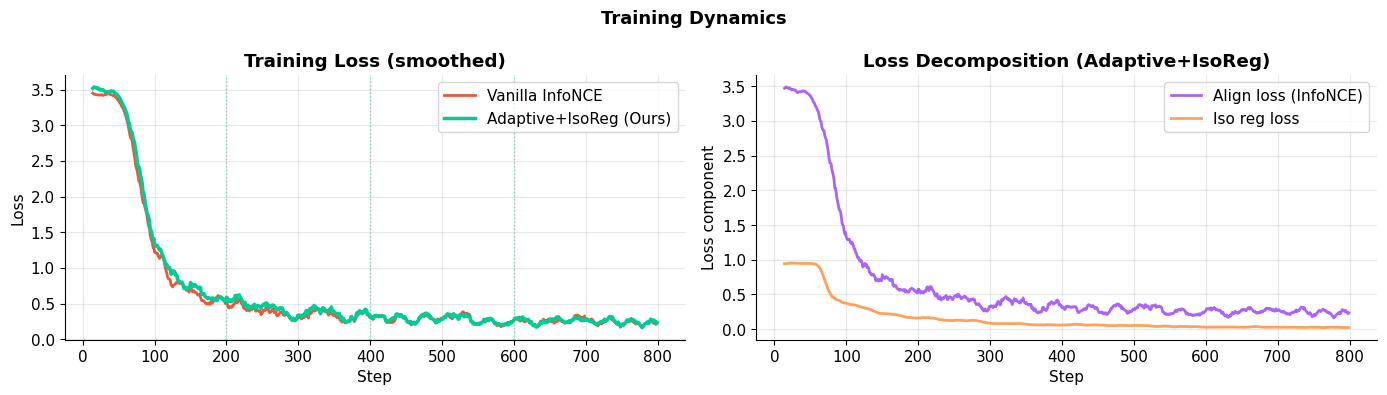

In [14]:
# ── Figure 3: Loss breakdown (align vs iso reg) ───────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
fig.suptitle('Training Dynamics', fontweight='bold', fontsize=13)

def smooth(x, w=15):
    return np.convolve(x, np.ones(w)/w, mode='valid')

steps_v = np.arange(len(losses_v))
steps_a = np.arange(len(losses_a))

# Loss curves
ax = axes[0]
ax.plot(steps_v[14:], smooth(losses_v), color=C['van'], lw=2, label=L['van'])
ax.plot(steps_a[14:], smooth(losses_a), color=C['ada'], lw=2.5, label=L['ada'])
if scale_history:
    for step_n, _ in scale_history:
        ax.axvline(step_n, color=C['ada'], ls=':', alpha=0.5, lw=1)
ax.set_xlabel('Step'); ax.set_ylabel('Loss')
ax.set_title('Training Loss (smoothed)', fontweight='bold')
ax.legend(); ax.grid(alpha=0.3)

# Isotropy reg vs align loss decomposition
ax = axes[1]
bd = np.array(loss_breakdown)
if len(bd) > 14:
    ax.plot(bd[14:, 0], smooth(bd[:, 2]), color='#AB63FA', lw=2, label='Align loss (InfoNCE)')
    ax.plot(bd[14:, 0], smooth(bd[:, 3]), color='#FFA15A', lw=2, label='Iso reg loss')
ax.set_xlabel('Step'); ax.set_ylabel('Loss component')
ax.set_title('Loss Decomposition (Adaptive+IsoReg)', fontweight='bold')
ax.legend(); ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('fig3_loss.png', dpi=150, bbox_inches='tight')
plt.show()

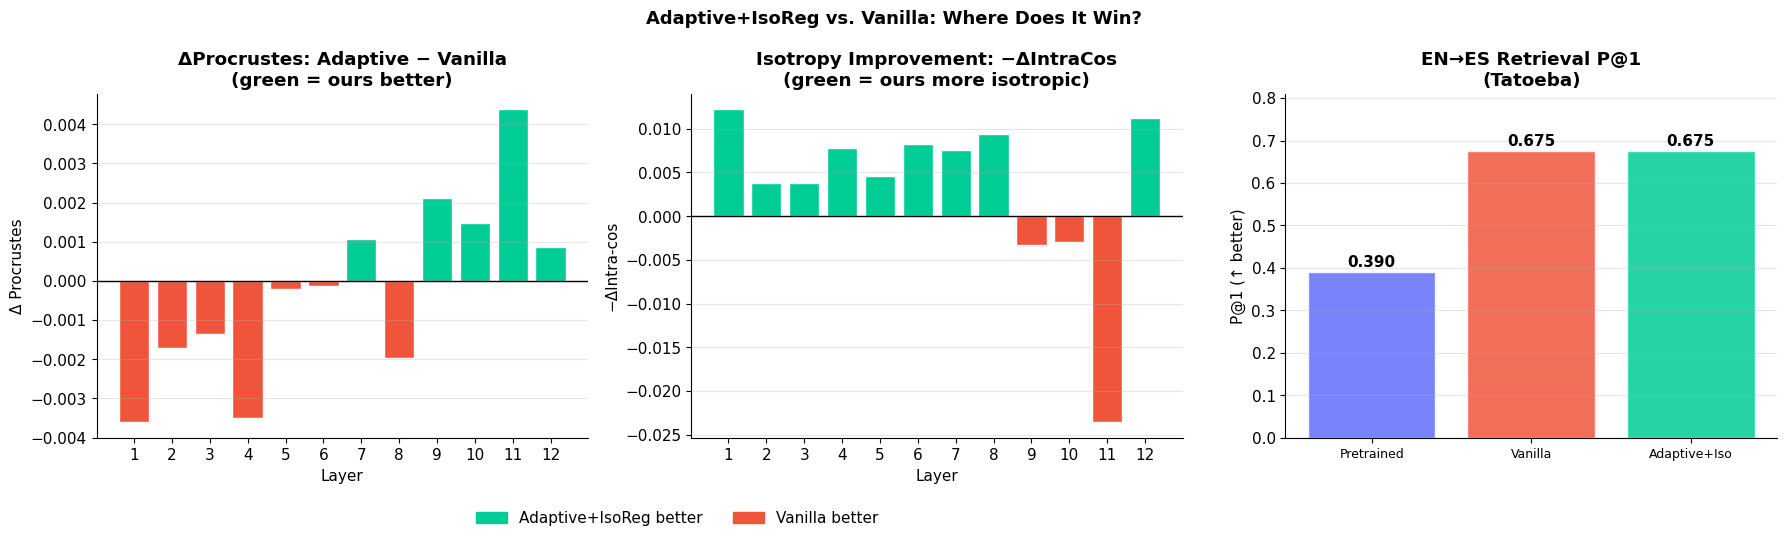

In [15]:
# ── Figure 4: Delta bars + retrieval summary ──────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Adaptive+IsoReg vs. Vanilla: Where Does It Win?',
             fontweight='bold', fontsize=13)

# 4a: ΔProcrustes
ax = axes[0]
delta_proc = np.array(adaptive_metrics['procrustes']) - np.array(vanilla_metrics['procrustes'])
cols = ['#00CC96' if d >= 0 else '#EF553B' for d in delta_proc]
ax.bar(layers, delta_proc, color=cols, edgecolor='white')
ax.axhline(0, color='black', lw=1)
ax.set_xlabel('Layer'); ax.set_ylabel('Δ Procrustes')
ax.set_title('ΔProcrustes: Adaptive − Vanilla\n(green = ours better)', fontweight='bold')
ax.set_xticks(layers); ax.grid(axis='y', alpha=0.3)

# 4b: ΔIntraCos (negative = ours better, so flip)
ax = axes[1]
delta_ic = -(np.array(adaptive_metrics['intracos']) - np.array(vanilla_metrics['intracos']))
cols = ['#00CC96' if d >= 0 else '#EF553B' for d in delta_ic]
ax.bar(layers, delta_ic, color=cols, edgecolor='white')
ax.axhline(0, color='black', lw=1)
ax.set_xlabel('Layer'); ax.set_ylabel('−ΔIntra-cos')
ax.set_title('Isotropy Improvement: −ΔIntraCos\n(green = ours more isotropic)', fontweight='bold')
ax.set_xticks(layers); ax.grid(axis='y', alpha=0.3)

# 4c: Retrieval P@1
ax = axes[2]
methods = list(retrieval.keys())
vals    = list(retrieval.values())
bar_c   = [C['pre'], C['van'], C['ada']]
bars = ax.bar(methods, vals, color=bar_c, alpha=0.85, edgecolor='white')
for bar, val in zip(bars, vals):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{val:.3f}', ha='center', va='bottom', fontweight='bold')
ax.set_ylabel('P@1 (↑ better)')
ax.set_title('EN→ES Retrieval P@1\n(Tatoeba)', fontweight='bold')
ax.set_xticklabels([m.replace(' ', '\n') for m in methods], fontsize=9)
ax.set_ylim(0, min(1.0, max(vals) * 1.2))
ax.grid(axis='y', alpha=0.3)

green_p = mpatches.Patch(color='#00CC96', label='Adaptive+IsoReg better')
red_p   = mpatches.Patch(color='#EF553B', label='Vanilla better')
fig.legend(handles=[green_p, red_p], loc='lower center', ncol=2,
           bbox_to_anchor=(0.38, -0.08), frameon=False)

plt.tight_layout()
plt.savefig('fig4_delta_retrieval.png', dpi=150, bbox_inches='tight')
plt.show()

In [16]:
# ── Final table ───────────────────────────────────────────────────────────────
def avg(d, k): return np.mean(d[k])

print('\n' + '='*62)
print('RESULTS SUMMARY')
print('='*62)
print(f'{"Metric":<30} {"Pretrained":>10} {"Vanilla":>10} {"Adaptive":>10}')
print('-'*62)
rows = [
    ('Procrustes (mean ↑)',    'procrustes', True),
    ('IntraCos (mean ↓)',      'intracos',   False),
    ('CKA cross-lingual (↑)',  'cka_cross',  True),
    ('CKA drift from pre (↑)', 'cka_drift',  True),
    ('Composite score (↑)',    'composite',  True),
]
for label, key, higher_better in rows:
    p = avg(pretrained_metrics, key)
    v = avg(vanilla_metrics,    key)
    a = avg(adaptive_metrics,   key)
    winner = '←' if (a > v if higher_better else a < v) else '  '
    print(f'{label:<30} {p:>10.4f} {v:>10.4f} {a:>10.4f} {winner}')
print('-'*62)
print(f'{"Retrieval P@1 (↑)":<30} {retrieval["Pretrained"]:>10.4f}'
      f' {retrieval["Vanilla"]:>10.4f} {retrieval["Adaptive+Iso"]:>10.4f}')
print('='*62)
print('← = Adaptive+IsoReg wins over Vanilla')


RESULTS SUMMARY
Metric                         Pretrained    Vanilla   Adaptive
--------------------------------------------------------------
Procrustes (mean ↑)                0.9326     0.9177     0.9175   
IntraCos (mean ↓)                  0.9428     0.8312     0.8280 ←
CKA cross-lingual (↑)              0.6877     0.6998     0.7175 ←
CKA drift from pre (↑)             1.0000     0.7015     0.7099 ←
Composite score (↑)                0.4612     0.5021     0.5035 ←
--------------------------------------------------------------
Retrieval P@1 (↑)                  0.3900     0.6750     0.6750
← = Adaptive+IsoReg wins over Vanilla


### Report for Layer 11

This section displays the geometry metrics specifically for layer 11, rather than the average across all layers. The interpretation of 'better' (indicated by ↑ or ↓) remains the same.

In [17]:
# Layer 11 corresponds to index 10 in the lists of layer-wise metrics
layer_index_to_report = 10

print('\n' + '='*62)
print(f'RESULTS SUMMARY FOR LAYER {layer_index_to_report + 1}')
print('='*62)
print(f'{"Metric":<30} {"Pretrained":>10} {"Vanilla":>10} {"Adaptive":>10}')
print('-'*62)
rows_layer_specific = [
    ('Procrustes (layer 11 ↑)', 'procrustes', True),
    ('IntraCos (layer 11 ↓)', 'intracos', False),
    ('CKA cross-lingual (layer 11 ↑)', 'cka_cross', True),
    ('CKA drift from pre (layer 11 ↑)', 'cka_drift', True),
    ('Composite score (layer 11 ↑)', 'composite', True),
]

for label, key, higher_better in rows_layer_specific:
    p = pretrained_metrics[key][layer_index_to_report]
    v = vanilla_metrics[key][layer_index_to_report]
    a = adaptive_metrics[key][layer_index_to_report]
    winner = '←' if (a > v if higher_better else a < v) else '  '
    print(f'{label:<30} {p:>10.4f} {v:>10.4f} {a:>10.4f} {winner}')
print('='*62)
print('← = Adaptive+IsoReg wins over Vanilla')


RESULTS SUMMARY FOR LAYER 11
Metric                         Pretrained    Vanilla   Adaptive
--------------------------------------------------------------
Procrustes (layer 11 ↑)            0.9418     0.9033     0.9077 ←
IntraCos (layer 11 ↓)              0.9646     0.6884     0.7120   
CKA cross-lingual (layer 11 ↑)     0.8677     0.9252     0.9194   
CKA drift from pre (layer 11 ↑)     1.0000     0.4293     0.3845   
Composite score (layer 11 ↑)       0.4595     0.5591     0.5517   
← = Adaptive+IsoReg wins over Vanilla
